## Exercise 1.4 Hotdog -- no hotdog
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

In [13]:
import os
import numpy as np
import glob
import PIL.Image as Image
from tqdm.notebook import tqdm
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

We always check that we are running on a GPU

In [14]:
if torch.cuda.is_available():
    print("The code will run on GPU.")
else:
    print("The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The code will run on GPU.


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [15]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path=os.path.join(os.getcwd(), "hotdog_nothotdog")):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y

Below is the simple way of converting the images to something that can be fed through a network.
Feel free to use something other than $128\times128$ images.

In [16]:
size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)),
                                    transforms.RandomHorizontalFlip(),
                                    transforms.RandomRotation(10),
                                    transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])

batch_size = 64
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)

Let's look at some images from our data 

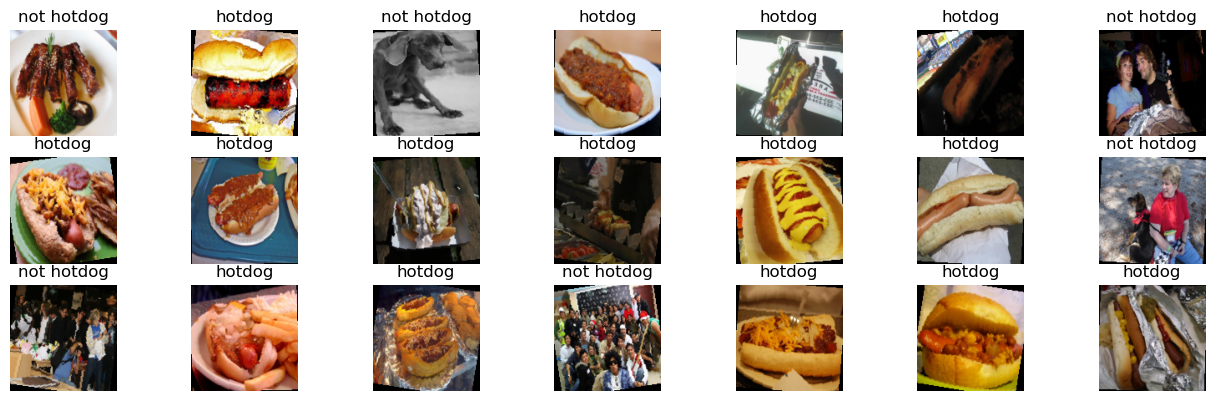

In [17]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(16,8))

for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1))
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')


Now create a model and train it!


In [18]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()
        
        # Feature Extraction
        self.convolutional = nn.Sequential(
            # First convolutional layer (32 x 128 x 128)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 32 x 64 x 64
            
            # Second convolutional layer (32 x 64 x 64)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 64 x 32 x 32
    
            # Third convolutional layer (64 x 32 x 32)
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 128 x 16 x 16

            # Fourth convolutional layer (128 x 16 x 16)
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Output: 256 x 8 x 8
        )
      
        self.fully_connected = nn.Sequential(
            nn.Flatten(), # 256 x 8 x 8 = 16384
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5), # Dropout for regularization
            nn.Linear(128, 1) # Output: 1 for binary classification
        )

    def forward(self, x):
        x = self.convolutional(x)
        x = x.view(x.size(0), -1)
        x = self.fully_connected(x)
        return x


In [19]:
model = CNN()
model.to(device)
criterion = nn.BCEWithLogitsLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

#Get the first minibatch
data = next(iter(train_loader))[0].cuda() # change from cuda to cpu when running on laptop without GPU
#Try running the model on a minibatch
print('Shape of the output from the convolutional part', model.convolutional(data).shape)
model(data); #if this runs the model dimensions fit

Shape of the output from the convolutional part torch.Size([64, 256, 8, 8])


In [20]:
# We create the training function that will be reused by the other model
def train(model, optimizer, num_epochs=10):
    def loss_fun(output, target):
        return criterion(output, target.float().unsqueeze(1))  # Ensure target has the same shape as output
    out_dict = {'train_acc': [],
              'test_acc': [],
              'train_loss': [],
              'test_loss': []}
  
    for epoch in tqdm(range(num_epochs), unit='epoch'):
        model.train()
        #For each epoch
        train_correct = 0
        train_loss = []
        for minibatch_no, (data, target) in tqdm(enumerate(train_loader), total=len(train_loader)):
            data, target = data.to(device), target.to(device)
            #Zero the gradients computed for each weight
            optimizer.zero_grad()
            #Forward pass your image through the network
            output = model(data)
            #Compute the loss
            loss = loss_fun(output, target)
            #Backward pass through the network
            loss.backward()
            #Update the weights
            optimizer.step()

            train_loss.append(loss.item())
            #Compute how many were correctly classified
            predicted = (output > 0).float().squeeze(1)
            train_correct += (target == predicted).sum().cpu().item()
            
        #Comput the test accuracy
        test_loss = []
        test_correct = 0
        model.eval()
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            with torch.no_grad():
                output = model(data)
            test_loss.append(loss_fun(output, target).cpu().item())
            predicted = (output > 0).float().squeeze(1)
            test_correct += (target == predicted).sum().cpu().item()
        out_dict['train_acc'].append(train_correct/len(trainset))
        out_dict['test_acc'].append(test_correct/len(testset))
        out_dict['train_loss'].append(np.mean(train_loss))
        out_dict['test_loss'].append(np.mean(test_loss))
        print(f"Loss train: {np.mean(train_loss):.3f}\t test: {np.mean(test_loss):.3f}\t",
              f"Accuracy train: {out_dict['train_acc'][-1]*100:.1f}%\t test: {out_dict['test_acc'][-1]*100:.1f}%")
    return out_dict

In [21]:
out_dict = train(model, optimizer, num_epochs=50)

  0%|          | 0/50 [00:00<?, ?epoch/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.587	 test: 0.671	 Accuracy train: 69.2%	 test: 57.0%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.499	 test: 0.504	 Accuracy train: 77.0%	 test: 76.1%


...

Loss train: 0.029	 test: 0.735	 Accuracy train: 99.0%	 test: 79.5%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.033	 test: 0.860	 Accuracy train: 99.0%	 test: 79.7%


  0%|          | 0/32 [00:00<?, ?it/s]

Loss train: 0.054	 test: 0.844	 Accuracy train: 97.8%	 test: 80.3%


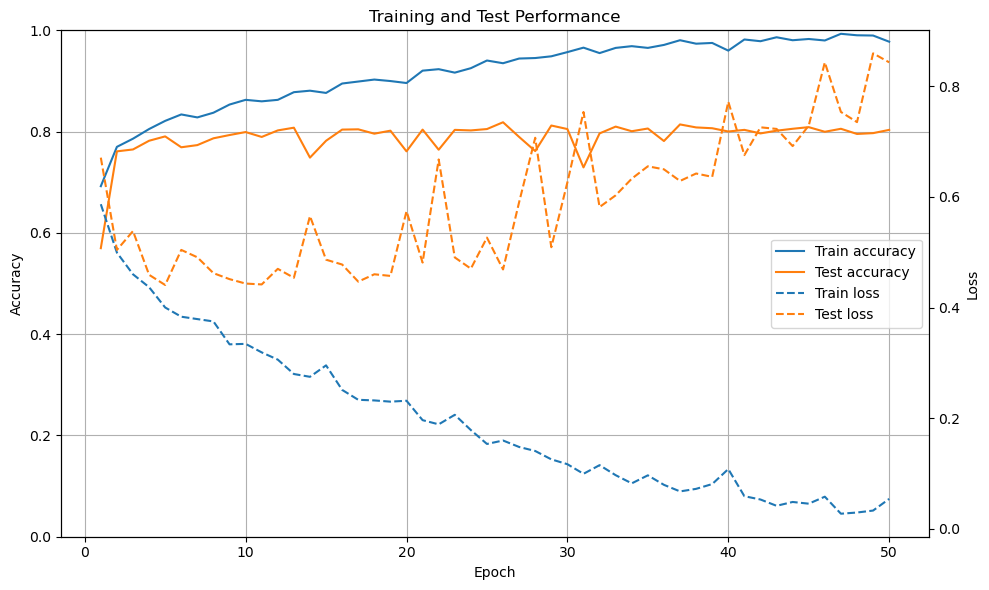

In [22]:
epochs = range(1, len(out_dict['train_acc']) + 1)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Accuracy — left y-axis
ax1.plot(epochs, out_dict['train_acc'], label='Train accuracy')
ax1.plot(epochs, out_dict['test_acc'], label='Test accuracy')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
ax1.grid(True)

# Loss — right y-axis
ax2 = ax1.twinx()

ax2.plot(epochs, out_dict['train_loss'], '--', label='Train loss')
ax2.plot(epochs, out_dict['test_loss'], '--', label='Test loss')

ax2.set_ylabel('Loss')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='center right'
)

plt.title('Training and Test Performance')
plt.tight_layout()
plt.show()

**Notes**:

when training the model, the training accuracy and loss improved increasingly while the test accuracy and loss decreased in improvement. This could indicate that the model is now overfitting to the dataset and we need to test using batch normalization and dropout to figure out if that's the difference. 

After including batch normalization the training and test accuracy is more parallel to each other now, which indicates that it works better. The accuracy is lower now though. The test loss is not going parallel with the training loss, so we need to optimize that too. 

After including data augmentation, the model accuracy and loss seems to stick more together. It can still be improved though, I want to get over 85% test accuracy.

After including dropout, I'm not sure that it helped. I think it needs to be removed because we have a small dataset and not a large model. Another thing is that the flattened layer has $256 \times 8 \times 8 = 4.1$ million parameters, so maybe use adaptive instead.

```
nn.AdaptiveAvgPool2d((1, 1)),
nn.Flatten(),
nn.Linear(256, 128)
```

In [23]:
# ============================================================
# ResNet18 Transfer Learning - Training + Evaluation (CHATGPT)
# ============================================================


# check if gpu is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# load weights
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Replace the final classifier
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)
criterion = nn.BCEWithLogitsLoss()

# Smaller learning rate than original CNN because we are fine-tuning pretrained weights.
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)


num_epochs = 50
history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": []
}


# training
for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.float().to(device)

        # Make labels shape [batch_size]
        labels = labels.view(-1)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images).view(-1)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predictions = (torch.sigmoid(outputs) >= 0.5).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

# testing
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.float().to(device)

            labels = labels.view(-1)

            # Forward pass
            outputs = model(images).view(-1)

            # Loss
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            # Predictions
            predictions = (torch.sigmoid(outputs) >= 0.5).float()

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    test_loss = running_loss / total
    test_accuracy = correct / total


# save and print statistics
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_accuracy)

    print(
        f"Epoch [{epoch + 1:02d}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_accuracy * 100:.2f}%"
    )

print("\nFinal results:")
print(f"Train accuracy: {history['train_accuracy'][-1] * 100:.2f}%")
print(f"Test accuracy:  {history['test_accuracy'][-1] * 100:.2f}%")
print(f"Train loss:     {history['train_loss'][-1]:.4f}")
print(f"Test loss:      {history['test_loss'][-1]:.4f}")

Using device: cuda
Epoch [01/50] | Train Loss: 0.3006 | Train Acc: 86.37% | Test Loss: 0.2319 | Test Acc: 90.76%
Epoch [02/50] | Train Loss: 0.1216 | Train Acc: 95.26% | Test Loss: 0.2131 | Test Acc: 92.11%
Epoch [03/50] | Train Loss: 0.0511 | Train Acc: 98.63% | Test Loss: 0.2253 | Test Acc: 91.14%
Epoch [04/50] | Train Loss: 0.0370 | Train Acc: 98.78% | Test Loss: 0.2258 | Test Acc: 91.89%
Epoch [05/50] | Train Loss: 0.0216 | Train Acc: 99.41% | Test Loss: 0.2377 | Test Acc: 92.64%
Epoch [06/50] | Train Loss: 0.0144 | Train Acc: 99.76% | Test Loss: 0.2761 | Test Acc: 91.78%
Epoch [07/50] | Train Loss: 0.0109 | Train Acc: 99.76% | Test Loss: 0.2600 | Test Acc: 92.00%
Epoch [08/50] | Train Loss: 0.0158 | Train Acc: 99.41% | Test Loss: 0.2678 | Test Acc: 91.68%
Epoch [09/50] | Train Loss: 0.0113 | Train Acc: 99.71% | Test Loss: 0.2744 | Test Acc: 91.51%
Epoch [10/50] | Train Loss: 0.0096 | Train Acc: 99.76% | Test Loss: 0.2886 | Test Acc: 92.27%
Epoch [11/50] | Train Loss: 0.0100 | Trai

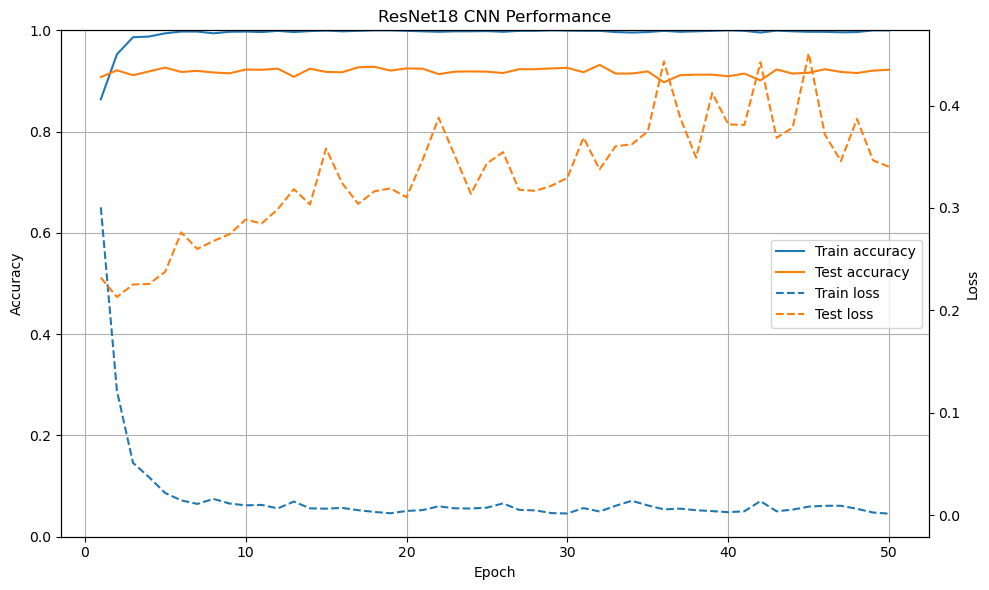

In [24]:
epochs = range(1, len(history['train_accuracy']) + 1)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Accuracy — left y-axis
ax1.plot(epochs, history['train_accuracy'], label='Train accuracy')
ax1.plot(epochs, history['test_accuracy'], label='Test accuracy')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
ax1.grid(True)

# Loss — right y-axis
ax2 = ax1.twinx()

ax2.plot(epochs, history['train_loss'], '--', label='Train loss')
ax2.plot(epochs, history['test_loss'], '--', label='Test loss')

ax2.set_ylabel('Loss')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='center right'
)

plt.title('ResNet18 CNN Performance')
plt.tight_layout()
plt.show()